In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Use GPU 0 (if you have multiple GPUs)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

In [3]:
filepath = r'D:\Academic\ML\ModelTraining\dataset\cicids2017_cleaned.csv'
df = pd.read_csv(filepath, low_memory=False)

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

# Severity mapping
severity_map = {
    'Normal Traffic': 'None',
    'Port Scanning':  'Medium',
    'Web Attacks':    'Medium',
    'DoS':            'Critical',
    'DDoS':           'Critical',
    'Brute Force':    'High',
    'Bots':           'High'
}
df['Severity'] = df['Attack Type'].map(severity_map)

print(df[['Attack Type', 'Severity']].drop_duplicates().sort_values('Attack Type'))
print(f"\nShape: {df.shape}")

            Attack Type  Severity
1534701            Bots      High
386275      Brute Force      High
807975             DDoS  Critical
1936573             DoS  Critical
0        Normal Traffic      None
1449      Port Scanning    Medium
225837      Web Attacks    Medium

Shape: (2520751, 54)


In [4]:
TARGET = 'Attack Type'
DROP_COLS = ['Attack Type', 'Severity']

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.30,
    random_state=42, stratify=y_enc
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Classes: ['Bots' 'Brute Force' 'DDoS' 'DoS' 'Normal Traffic' 'Port Scanning'
 'Web Attacks']
Train: (1764525, 52), Test: (756226, 52)


In [5]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(184.80571847507332), np.int64(1): np.float64(39.3559718969555), np.int64(2): np.float64(2.8130231001004353), np.int64(3): np.float64(1.8586723295064924), np.int64(4): np.float64(0.17188427992709365), np.int64(5): np.float64(3.9705604385218787), np.int64(6): np.float64(168.05)}


Training Random Forest with OOB tracking...
  n_estimators=10, OOB Error=0.0777
  n_estimators=20, OOB Error=0.0480
  n_estimators=30, OOB Error=0.0348
  n_estimators=40, OOB Error=0.0272
  n_estimators=50, OOB Error=0.0223
  n_estimators=60, OOB Error=0.0189
  n_estimators=70, OOB Error=0.0163
  n_estimators=80, OOB Error=0.0144
  n_estimators=90, OOB Error=0.0128
  n_estimators=100, OOB Error=0.0116
  n_estimators=110, OOB Error=0.0105
  n_estimators=120, OOB Error=0.0097
  n_estimators=130, OOB Error=0.0090
  n_estimators=140, OOB Error=0.0086
  n_estimators=150, OOB Error=0.0081
  n_estimators=160, OOB Error=0.0077
  n_estimators=170, OOB Error=0.0074
  n_estimators=180, OOB Error=0.0072
  n_estimators=190, OOB Error=0.0070
  n_estimators=200, OOB Error=0.0068


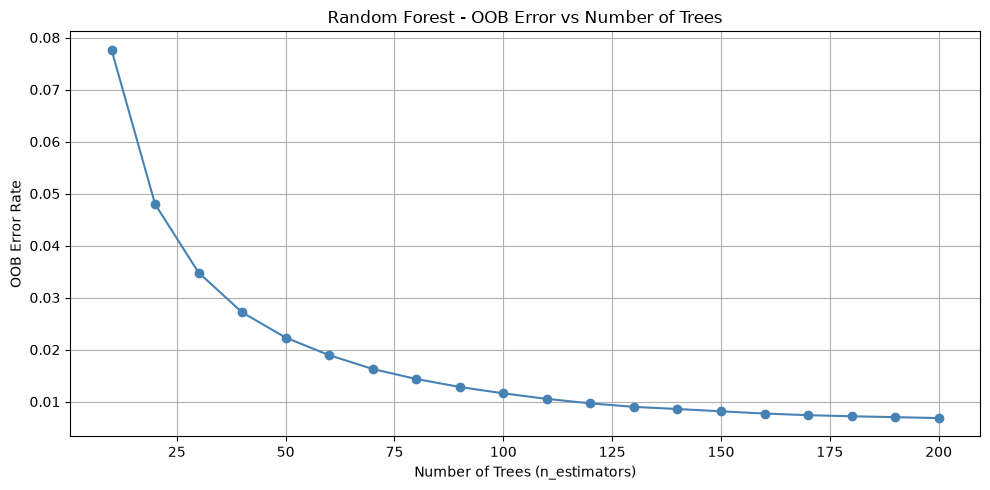


Best n_estimators by OOB error: 200
Final RF model trained with n_estimators=200


In [6]:
oob_errors = []
estimator_range = range(10, 201, 10)

print("Training Random Forest with OOB tracking...")
for n in estimator_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        class_weight=class_weight_dict,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)
    print(f"  n_estimators={n}, OOB Error={oob_errors[-1]:.4f}")

# Plot OOB error curve
plt.figure(figsize=(10, 5))
plt.plot(list(estimator_range), oob_errors, marker='o', color='steelblue')
plt.title('Random Forest - OOB Error vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('OOB Error Rate')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\output\rf_oob_curve.png', dpi=150)
plt.show()

# Pick the n_estimators with lowest OOB error
best_n = list(estimator_range)[np.argmin(oob_errors)]
print(f"\nBest n_estimators by OOB error: {best_n}")

# Train final RF model with best n_estimators
rf_model = RandomForestClassifier(
    n_estimators=best_n,
    oob_score=False,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print(f"Final RF model trained with n_estimators={best_n}")

[0]	validation_0-mlogloss:1.65948	validation_1-mlogloss:1.65929
[20]	validation_0-mlogloss:0.23819	validation_1-mlogloss:0.23814
[40]	validation_0-mlogloss:0.05687	validation_1-mlogloss:0.05697
[60]	validation_0-mlogloss:0.02293	validation_1-mlogloss:0.02311
[80]	validation_0-mlogloss:0.01232	validation_1-mlogloss:0.01258
[100]	validation_0-mlogloss:0.00898	validation_1-mlogloss:0.00929
[120]	validation_0-mlogloss:0.00754	validation_1-mlogloss:0.00793
[140]	validation_0-mlogloss:0.00679	validation_1-mlogloss:0.00722
[160]	validation_0-mlogloss:0.00623	validation_1-mlogloss:0.00669
[180]	validation_0-mlogloss:0.00591	validation_1-mlogloss:0.00641
[199]	validation_0-mlogloss:0.00570	validation_1-mlogloss:0.00624


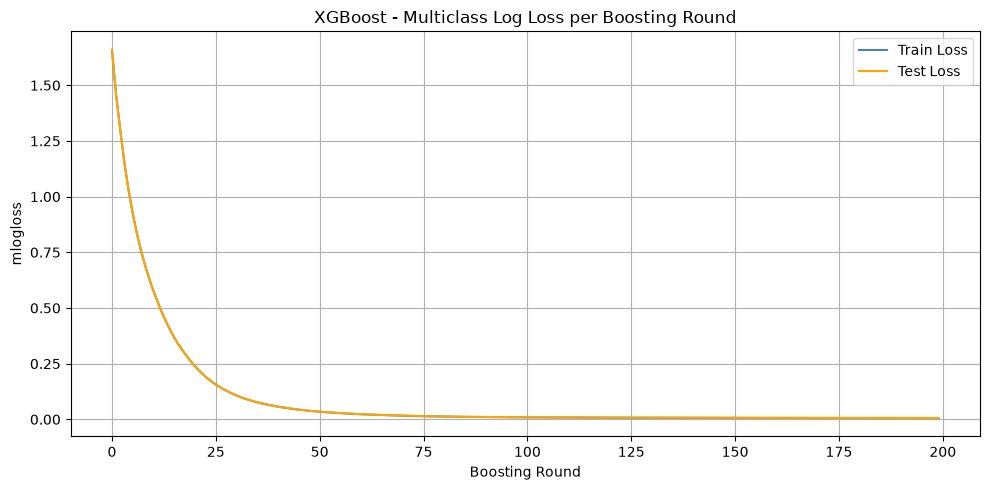

In [8]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

eval_results = {}

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=20
)

results = xgb_model.evals_result()

# Plot XGBoost loss curve
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['mlogloss'], label='Train Loss', color='steelblue')
plt.plot(results['validation_1']['mlogloss'], label='Test Loss', color='orange')
plt.title('XGBoost - Multiclass Log Loss per Boosting Round')
plt.xlabel('Boosting Round')
plt.ylabel('mlogloss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\output\xgb_loss_curve.png', dpi=150)
plt.show()

In [12]:
from sklearn import set_config
set_config(enable_metadata_routing=False)

# Reuse rf_model from cell 5 — no need to retrain
xgb_base = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    num_class=len(le.classes_),
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

ensemble = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_base)],
    voting='soft',
    n_jobs=-1
)

print("Training Ensemble (RF reused from cell 5, XGBoost retraining)...")
ensemble.fit(X_train, y_train)
print("Ensemble training complete.")

Training Ensemble (RF reused from cell 5, XGBoost retraining)...
Ensemble training complete.



Random Forest - Accuracy: 0.9984
                precision    recall  f1-score   support

          Bots       0.50      0.96      0.66       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.98      0.98      0.98       643

      accuracy                           1.00    756226
     macro avg       0.92      0.99      0.95    756226
  weighted avg       1.00      1.00      1.00    756226



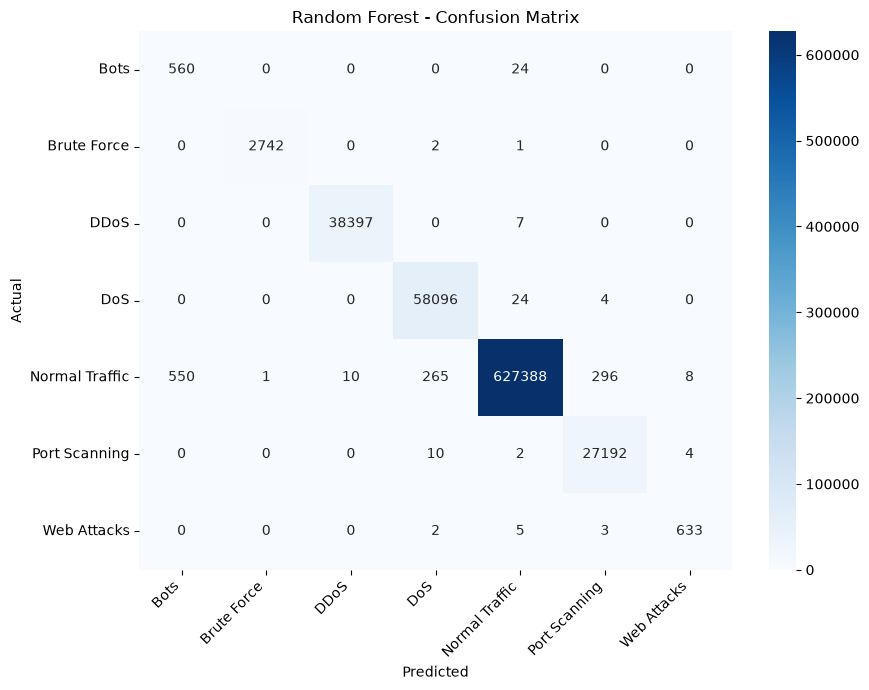


XGBoost - Accuracy: 0.9989
                precision    recall  f1-score   support

          Bots       0.63      0.99      0.77       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.98      1.00      0.99       643

      accuracy                           1.00    756226
     macro avg       0.94      1.00      0.96    756226
  weighted avg       1.00      1.00      1.00    756226



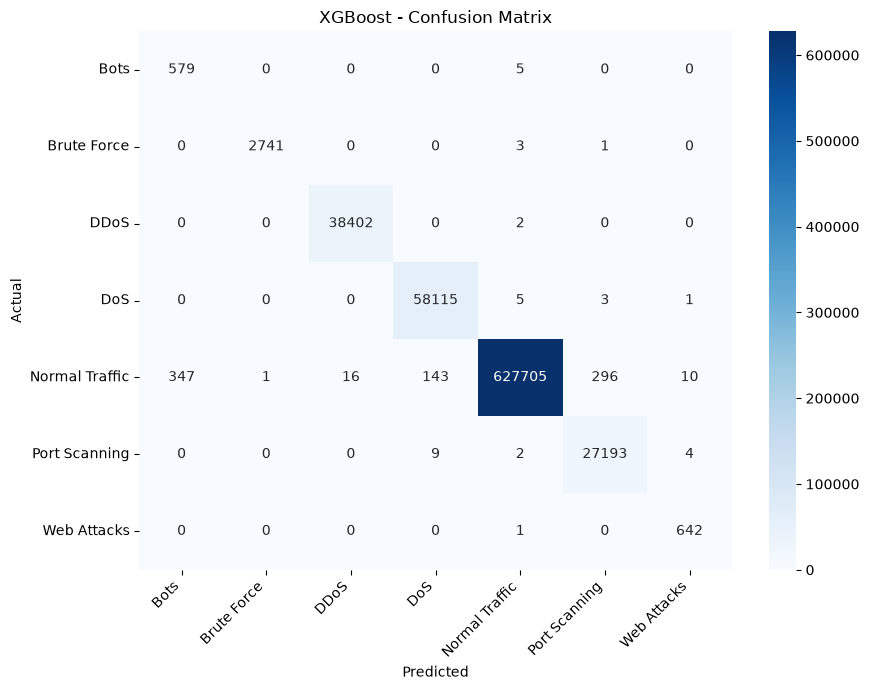


Voting Ensemble - Accuracy: 0.9991
                precision    recall  f1-score   support

          Bots       0.71      0.93      0.80       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.99      0.98      0.99       643

      accuracy                           1.00    756226
     macro avg       0.96      0.99      0.97    756226
  weighted avg       1.00      1.00      1.00    756226



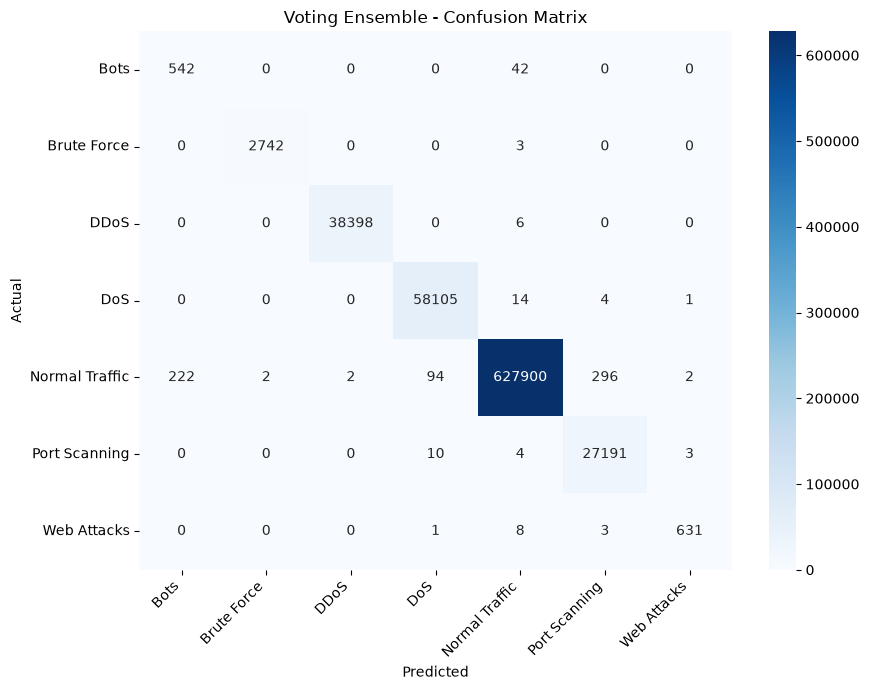

In [13]:
def evaluate_model(model, X_test, y_test, le, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=le.classes_,
                                   output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{'='*50}")
    print(f"{name} - Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion matrix
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(rf'D:\Academic\ML\ModelTraining\output\{name.lower().replace(" ", "_")}_cm.png', dpi=150)
    plt.show()

    return acc, report

rf_acc,  rf_report  = evaluate_model(rf_model,  X_test, y_test, le, 'Random Forest')
xgb_acc, xgb_report = evaluate_model(xgb_model, X_test, y_test, le, 'XGBoost')
ens_acc, ens_report = evaluate_model(ensemble,  X_test, y_test, le, 'Voting Ensemble')

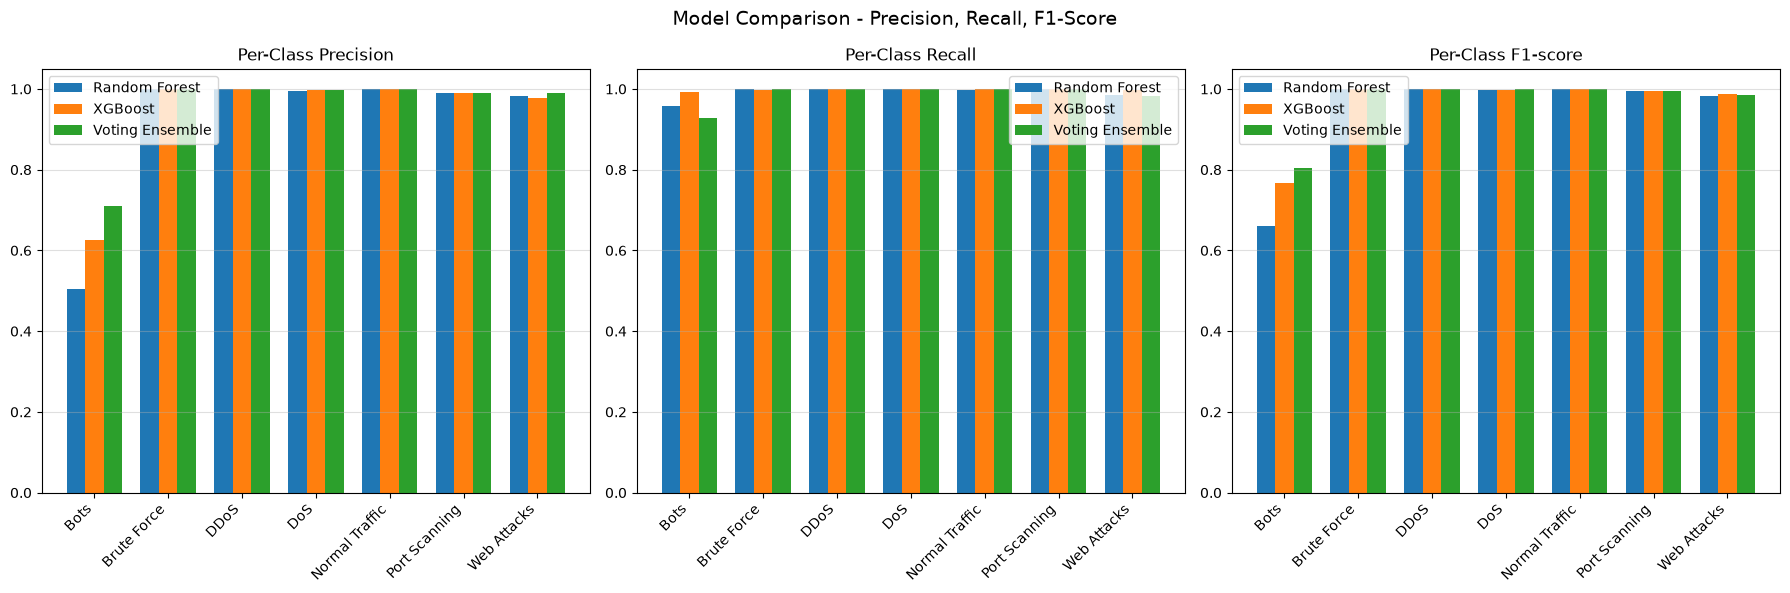

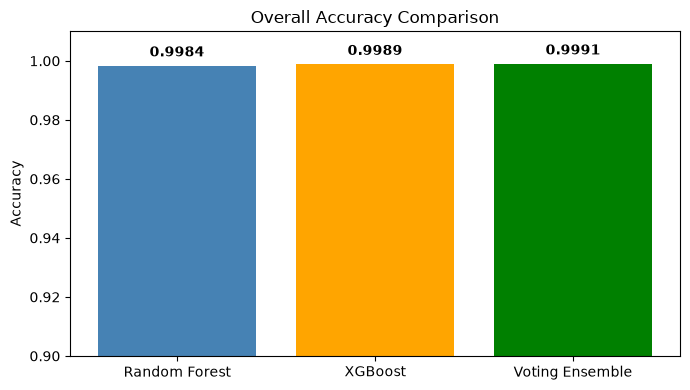

In [14]:
models = ['Random Forest', 'XGBoost', 'Voting Ensemble']
reports = [rf_report, xgb_report, ens_report]
classes = le.classes_

metrics = ['precision', 'recall', 'f1-score']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(metrics):
    values = {m: [reports[j][cls][metric] for cls in classes]
              for j, m in enumerate(models)}
    x = np.arange(len(classes))
    width = 0.25

    for k, (model_name, vals) in enumerate(values.items()):
        axes[i].bar(x + k * width, vals, width, label=model_name)

    axes[i].set_title(f'Per-Class {metric.capitalize()}')
    axes[i].set_xticks(x + width)
    axes[i].set_xticklabels(classes, rotation=45, ha='right')
    axes[i].set_ylim(0, 1.05)
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.4)

plt.suptitle('Model Comparison - Precision, Recall, F1-Score', fontsize=14)
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\output\model_comparison.png', dpi=150)
plt.show()

# Overall accuracy bar
plt.figure(figsize=(7, 4))
accs = [rf_acc, xgb_acc, ens_acc]
bars = plt.bar(models, accs, color=['steelblue', 'orange', 'green'])
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0.9, 1.01)
plt.title('Overall Accuracy Comparison')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig(r'D:\Academic\ML\ModelTraining\output\accuracy_comparison.png', dpi=150)
plt.show()

In [15]:
joblib.dump(rf_model,  r'D:\Academic\ML\ModelTraining\output\rf_model.pkl')
joblib.dump(xgb_model, r'D:\Academic\ML\ModelTraining\output\xgb_model.pkl')
joblib.dump(ensemble,  r'D:\Academic\ML\ModelTraining\output\ensemble_model.pkl')
joblib.dump(scaler,    r'D:\Academic\ML\ModelTraining\output\scaler.pkl')
joblib.dump(le,        r'D:\Academic\ML\ModelTraining\output\label_encoder.pkl')

print("Saved:")
for f in os.listdir(r'D:\Academic\ML\ModelTraining\output'):
    if f.endswith('.pkl') or f.endswith('.png'):
        size = os.path.getsize(rf'D:\Academic\ML\ModelTraining\output\{f}') / (1024**2)
        print(f"  {f} - {size:.2f} MB")

Saved:
  accuracy_comparison.png - 0.03 MB
  ensemble_model.pkl - 152.28 MB
  label_encoder.pkl - 0.00 MB
  model_comparison.png - 0.09 MB
  random_forest_cm.png - 0.08 MB
  rf_model.pkl - 74.79 MB
  rf_oob_curve.png - 0.05 MB
  scaler.pkl - 0.00 MB
  voting_ensemble_cm.png - 0.08 MB
  xgboost_cm.png - 0.08 MB
  xgb_loss_curve.png - 0.05 MB
  xgb_model.pkl - 2.82 MB


In [16]:
import time
import datetime

# ── Configuration ──────────────────────────────────────────────────────────────
REPLAY_DELAY = 0.5
NUM_FLOWS    = 200
ALERT_LOG    = r'D:\Academic\ML\ModelTraining\output\alert_log.csv'
NORMAL_LABEL = 'Normal Traffic'

# ── Prepare replay data ────────────────────────────────────────────────────────
if NUM_FLOWS is not None:
    X_replay = X_test[:NUM_FLOWS]
    y_replay = y_test[:NUM_FLOWS]
else:
    X_replay = X_test
    y_replay = y_test

# ── Alert log setup ────────────────────────────────────────────────────────────
alert_records = []

print(f"{'─'*70}")
print(f"{'FLOW #':<8} {'TIMESTAMP':<22} {'RF':<18} {'XGB':<18} {'ENSEMBLE':<18} {'ALERT'}")
print(f"{'─'*70}")

# ── Replay loop ────────────────────────────────────────────────────────────────
for i in range(len(X_replay)):
    flow       = X_replay[i].reshape(1, -1)
    true_label = le.inverse_transform([y_replay[i]])[0]
    timestamp  = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]

    rf_pred  = le.inverse_transform(rf_model.predict(flow))[0]
    xgb_pred = le.inverse_transform(xgb_model.predict(flow))[0]
    ens_pred = le.inverse_transform(ensemble.predict(flow))[0]

    ens_proba      = ensemble.predict_proba(flow)[0]
    ens_confidence = round(float(np.max(ens_proba)) * 100, 2)

    is_alert  = ens_pred != NORMAL_LABEL
    alert_str = f"⚠ ALERT: {ens_pred}" if is_alert else "✓ Normal"

    print(f"{i+1:<8} {timestamp:<22} {rf_pred:<18} {xgb_pred:<18} {ens_pred:<18} {alert_str}")

    alert_records.append({
        'flow_index'            : i + 1,
        'timestamp'             : timestamp,
        'true_label'            : true_label,
        'rf_prediction'         : rf_pred,
        'xgb_prediction'        : xgb_pred,
        'ensemble_prediction'   : ens_pred,
        'ensemble_confidence_%' : ens_confidence,
        'alert_triggered'       : is_alert,
        'attack_type'           : ens_pred if is_alert else 'None'
    })

    time.sleep(REPLAY_DELAY)

print(f"{'─'*70}")

# ── Save alert log ─────────────────────────────────────────────────────────────
alert_df = pd.DataFrame(alert_records)
alert_df.to_csv(ALERT_LOG, index=False)
print(f"\nAlert log saved to {ALERT_LOG}")

# ── Summary ────────────────────────────────────────────────────────────────────
total_flows  = len(alert_df)
total_alerts = alert_df['alert_triggered'].sum()
alert_breakdown = (
    alert_df[alert_df['alert_triggered']]
    ['attack_type']
    .value_counts()
)

print(f"\n{'─'*40}")
print(f"REPLAY SUMMARY")
print(f"{'─'*40}")
print(f"Total flows processed : {total_flows}")
print(f"Alerts triggered      : {total_alerts}")
print(f"Normal flows          : {total_flows - total_alerts}")
print(f"\nAlert breakdown by attack type:")
print(alert_breakdown.to_string())
print(f"{'─'*40}")

──────────────────────────────────────────────────────────────────────
FLOW #   TIMESTAMP              RF                 XGB                ENSEMBLE           ALERT
──────────────────────────────────────────────────────────────────────
1        2026-07-20 15:17:49.276 Normal Traffic     Normal Traffic     Normal Traffic     ✓ Normal
2        2026-07-20 15:17:49.899 Normal Traffic     Normal Traffic     Normal Traffic     ✓ Normal
3        2026-07-20 15:17:50.500 Normal Traffic     Normal Traffic     Normal Traffic     ✓ Normal
4        2026-07-20 15:17:51.102 Normal Traffic     Normal Traffic     Normal Traffic     ✓ Normal
5        2026-07-20 15:17:51.706 Normal Traffic     Normal Traffic     Normal Traffic     ✓ Normal
6        2026-07-20 15:17:52.297 DoS                DoS                DoS                ⚠ ALERT: DoS
7        2026-07-20 15:17:52.890 Normal Traffic     Normal Traffic     Normal Traffic     ✓ Normal
8        2026-07-20 15:17:53.503 Normal Traffic     Normal Traffic